# Классификация изображений Fashion MNIST с использованием PyTorch

## Цель проекта

Целью проекта является разработка и исследование нейронной сети для классификации изображений одежды из набора данных Fashion MNIST с использованием библиотеки PyTorch.

В рамках проекта выполняются следующие этапы:

* анализ набора данных;
* подготовка данных;
* построение нейронной сети;
* обучение и оценка модели;
* подбор гиперпараметров;
* анализ ошибок модели;
* проверка устойчивости модели к шуму.

Конечной целью является получение модели, способной классифицировать изображения одежды с высокой точностью и выявление факторов, влияющих на качество классификации.

# Подготовка данных

Для подготовки данных изображения были преобразованы в тензоры PyTorch и нормализованы в диапазон значений от 0 до 1.

Обучающая выборка была разделена на две части:

* обучающая выборка — 55 000 изображений;
* валидационная выборка — 5 000 изображений.

Тестовая выборка содержит 10 000 изображений и используется только для финальной оценки качества модели.

Для пакетной загрузки данных были созданы объекты DataLoader.


In [103]:
import torch
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

# Анализ набора данных

Fashion MNIST представляет собой набор изображений предметов одежды в оттенках серого.

Характеристики датасета:

* 60 000 изображений для обучения;
* 10 000 изображений для тестирования;
* размер изображения: 28 × 28 пикселей;
* 10 классов одежды.

Перед обучением модели были исследованы основные характеристики данных:

* размеры выборок;
* размеры изображений;
* диапазон значений пикселей;
* список классов;
* баланс классов.

In [104]:
print(len(train_data))
print(len(valid_data))
print(len(test_data))

X_sample, y_sample = train_data[0]
print(X_sample.shape)
print(X_sample.dtype)
print(X_sample.min(), X_sample.max())
print(train_and_valid_data.classes)

55000
5000
10000
torch.Size([1, 28, 28])
torch.float32
tensor(0.) tensor(1.)
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [105]:
from collections import Counter

train_labels = [label for _, label in train_data]
valid_labels = [label for _, label in valid_data]
test_labels = [label for _, label in test_data]

print(Counter(train_labels))
print(Counter(valid_labels))
print(Counter(test_labels))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000001487855DE40>
Traceback (most recent call last):
  File "c:\Users\miste\anaconda3\envs\geron_ml\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "c:\Users\miste\anaconda3\envs\geron_ml\Lib\site-packages\torch\utils\data\dataloader.py", line 1667, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Counter({7: 5555, 3: 5524, 6: 5510, 8: 5508, 9: 5507, 5: 5491, 1: 5490, 4: 5490, 2: 5473, 0: 5452})
Counter({0: 548, 2: 527, 4: 510, 1: 510, 5: 509, 9: 493, 8: 492, 6: 490, 3: 476, 7: 445})
Counter({9: 1000, 2: 1000, 1: 1000, 6: 1000, 4: 1000, 5: 1000, 7: 1000, 3: 1000, 8: 1000, 0: 1000})


In [106]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, num_workers=4, pin_memory=True)

X_sample, y_sample = train_data[0]
train_and_valid_data.classes[y_sample]

'Ankle boot'

# Архитектура модели

В качестве базовой модели был выбран многослойный перцептрон (MLP).

Архитектура сети:

Входной слой:

* 784 нейрона (28 × 28 пикселей).

Скрытые слои:

* 300 нейронов + функция активации ReLU;
* 100 нейронов + функция активации ReLU.

Выходной слой:

* 10 нейронов (по одному для каждого класса).

Для обучения модели используется функция потерь CrossEntropyLoss, а оптимизация выполняется алгоритмами SGD и Adam.

In [107]:
import torch.nn as nn

class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10)
xentropy = nn.CrossEntropyLoss()

In [108]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)

cuda


In [109]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset() 
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  
    return metric.compute()  

# Обучение базовой модели

Базовая модель обучается методом мини-пакетного градиентного спуска.

В процессе обучения отслеживаются следующие показатели:

* значение функции потерь (Loss);
* точность на обучающей выборке (Train Accuracy);
* точность на валидационной выборке (Validation Accuracy).

Валидационная выборка используется для оценки способности модели обобщать знания на ранее не встречавшихся данных.

In [110]:
from copy import deepcopy

def train(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

    best_valid_accuracy = 0
    best_model_state = None
    best_epoch = 0
    
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        mean_loss = total_loss / len(train_loader)
        train_accuracy = metric.compute().item()
        valid_accuracy = evaluate_tm(model, valid_loader, metric).item()

        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(train_accuracy)
        history["valid_metrics"].append(valid_accuracy)

        if valid_accuracy > best_valid_accuracy:
            best_valid_accuracy = valid_accuracy
            best_model_state = deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        
    return history, best_model_state, best_valid_accuracy, best_epoch

In [111]:
import torchmetrics

model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
n_epochs = 20
history, baseline_best_model_state, baseline_best_valid_accuracy, baseline_best_epoch = train(model, optimizer, xentropy, accuracy, train_loader, valid_loader,
           n_epochs)
model.load_state_dict(baseline_best_model_state)

Epoch 1/20, train loss: 0.6059, train metric: 0.7810, valid metric: 0.8426
Epoch 2/20, train loss: 0.4057, train metric: 0.8501, valid metric: 0.8392
Epoch 3/20, train loss: 0.3629, train metric: 0.8659, valid metric: 0.8556
Epoch 4/20, train loss: 0.3352, train metric: 0.8770, valid metric: 0.8642
Epoch 5/20, train loss: 0.3144, train metric: 0.8843, valid metric: 0.8774
Epoch 6/20, train loss: 0.2996, train metric: 0.8870, valid metric: 0.8626
Epoch 7/20, train loss: 0.2852, train metric: 0.8921, valid metric: 0.8774
Epoch 8/20, train loss: 0.2749, train metric: 0.8966, valid metric: 0.8746
Epoch 9/20, train loss: 0.2641, train metric: 0.9009, valid metric: 0.8810
Epoch 10/20, train loss: 0.2540, train metric: 0.9027, valid metric: 0.8766
Epoch 11/20, train loss: 0.2463, train metric: 0.9065, valid metric: 0.8848
Epoch 12/20, train loss: 0.2367, train metric: 0.9099, valid metric: 0.8868
Epoch 13/20, train loss: 0.2294, train metric: 0.9123, valid metric: 0.8866
Epoch 14/20, train lo

<All keys matched successfully>

In [112]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)

In [113]:
test_accuracy = evaluate_tm(model, test_loader, accuracy)
print(f"Test accuracy: {test_accuracy.item():.4f}")

Test accuracy: 0.8890


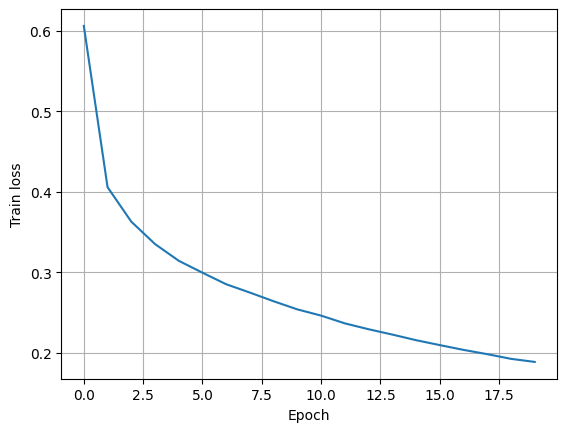

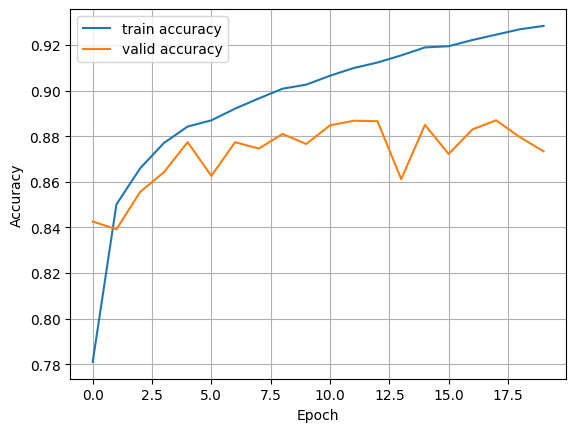

In [114]:
import matplotlib.pyplot as plt

plt.plot(history["train_losses"])
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.grid()
plt.show()

plt.plot(history["train_metrics"], label="train accuracy")
plt.plot(history["valid_metrics"], label="valid accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Эксперименты с гиперпараметрами

Для исследования влияния гиперпараметров на качество модели были проведены несколько экспериментов.

Были рассмотрены различные комбинации:

* оптимизатор SGD с learning rate = 0.1;
* оптимизатор SGD с learning rate = 0.01;
* оптимизатор Adam с learning rate = 0.001.

Сравнение моделей выполнялось по точности на валидационной и тестовой выборках.

In [115]:
experiments = [
    {
        "name": "SGD lr=0.1",
        "optimizer": "SGD",
        "lr": 0.1,
        "n_hidden1": 300,
        "n_hidden2": 100,
    },
    {
        "name": "SGD lr=0.01",
        "optimizer": "SGD",
        "lr": 0.01,
        "n_hidden1": 300,
        "n_hidden2": 100,
    },
    {
        "name": "Adam lr=0.001",
        "optimizer": "Adam",
        "lr": 0.001,
        "n_hidden1": 300,
        "n_hidden2": 100,
    },
]

In [ ]:
results = []

best_overall_valid_accuracy = 0
best_overall_model_state = None
best_overall_experiment = None
best_overall_config = None

for exp in experiments:
    print(f"\nExperiment: {exp['name']}")

    torch.manual_seed(42)

    model = ImageClassifier(
        n_inputs=28 * 28,
        n_hidden1=exp["n_hidden1"],
        n_hidden2=exp["n_hidden2"],
        n_classes=10
    ).to(device)

    if exp["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=exp["lr"])
    elif exp["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=exp["lr"])

    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=10
    ).to(device)

    history, best_model_state, best_valid_accuracy, best_epoch = train(
        model,
        optimizer,
        xentropy,
        accuracy,
        train_loader,
        valid_loader,
        n_epochs=10
    )

    model.load_state_dict(best_model_state)

    test_accuracy = evaluate_tm(model, test_loader, accuracy).item()

    results.append({
        "name": exp["name"],
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "n_hidden1": exp["n_hidden1"],
        "n_hidden2": exp["n_hidden2"],
        "best_epoch": best_epoch,
        "best_valid_accuracy": best_valid_accuracy,
        "test_accuracy": test_accuracy,
    })

    if best_valid_accuracy > best_overall_valid_accuracy:
        best_overall_valid_accuracy = best_valid_accuracy
        best_overall_model_state = deepcopy(best_model_state)
        best_overall_experiment = exp["name"]
        best_overall_config = exp


Experiment: SGD lr=0.1
Epoch 1/10, train loss: 0.6059, train metric: 0.7810, valid metric: 0.8426
Epoch 2/10, train loss: 0.4057, train metric: 0.8501, valid metric: 0.8392
Epoch 3/10, train loss: 0.3629, train metric: 0.8659, valid metric: 0.8556
Epoch 4/10, train loss: 0.3352, train metric: 0.8770, valid metric: 0.8642
Epoch 5/10, train loss: 0.3144, train metric: 0.8843, valid metric: 0.8774
Epoch 6/10, train loss: 0.2996, train metric: 0.8870, valid metric: 0.8626
Epoch 7/10, train loss: 0.2852, train metric: 0.8921, valid metric: 0.8774
Epoch 8/10, train loss: 0.2749, train metric: 0.8966, valid metric: 0.8746
Epoch 9/10, train loss: 0.2641, train metric: 0.9009, valid metric: 0.8810
Epoch 10/10, train loss: 0.2540, train metric: 0.9027, valid metric: 0.8766

Experiment: SGD lr=0.01


## Анализ результатов экспериментов

Наилучший результат показала модель с оптимизатором Adam и learning rate = 0.001.

Также было установлено, что уменьшение learning rate для SGD с 0.1 до 0.01 привело к ухудшению качества модели.

Полученные результаты показывают, что выбор learning rate оказывает существенное влияние на качество классификации.

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,name,optimizer,lr,best_valid_accuracy,test_accuracy
0,SGD lr=0.1,SGD,0.100,0.8810,0.8706
1,SGD lr=0.01,SGD,0.010,0.8572,0.8520
2,Adam lr=0.001,Adam,0.001,0.8850,0.8734


In [ ]:
best_model = ImageClassifier(
    n_inputs=28 * 28,
    n_hidden1=best_overall_config["n_hidden1"],
    n_hidden2=best_overall_config["n_hidden2"],
    n_classes=10
).to(device)

best_model.load_state_dict(best_overall_model_state)

print(f"Best model: {best_overall_experiment}")
print(f"Best valid accuracy: {best_overall_valid_accuracy:.4f}")

# Анализ ошибок модели

Для более детального анализа качества классификации была построена матрица ошибок (Confusion Matrix).

Матрица ошибок позволяет определить:

* какие классы модель распознаёт лучше всего;
* какие классы чаще всего путаются между собой;
* какие категории одежды являются наиболее сложными для классификации.

Также были рассмотрены примеры ошибочных предсказаний модели.

In [ ]:
all_preds = []
all_labels = []

best_model.eval()

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = best_model(X_batch)
        preds = logits.argmax(dim=1).cpu()

        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

ConfusionMatrixDisplay(
    cm,
    display_labels=train_and_valid_data.classes
).plot(xticks_rotation=45)

plt.show()

In [ ]:
wrong_indices = (all_preds != all_labels).nonzero().squeeze()

for idx in wrong_indices[:10]:
    image, true_label = test_data[idx]
    pred_label = all_preds[idx].item()

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"True: {train_and_valid_data.classes[true_label]}, "
        f"Pred: {train_and_valid_data.classes[pred_label]}"
    )
    plt.axis("off")
    plt.show()

# Проверка устойчивости модели к шуму

Для оценки устойчивости модели к искажениям входных данных был проведён эксперимент с добавлением случайного гауссовского шума к изображениям тестовой выборки.

Цель эксперимента — определить, насколько сильно снижается качество классификации при ухудшении качества входных изображений.

Чем медленнее падает точность при увеличении уровня шума, тем более устойчивой считается модель.

In [ ]:
def add_noise(X, noise_level=0.2):
    noise = torch.randn_like(X) * noise_level
    X_noisy = X + noise
    return torch.clamp(X_noisy, 0, 1)

In [ ]:
def evaluate_on_noisy_data(model, data_loader, metric, noise_level=0.2):
    model.eval()
    metric.reset()

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            X_batch_noisy = add_noise(X_batch, noise_level=noise_level)

            y_pred = model(X_batch_noisy)
            metric.update(y_pred, y_batch)

    return metric.compute()

## Анализ устойчивости модели

При увеличении уровня шума точность классификации постепенно снижается.

Модель сохраняет высокую точность при небольших уровнях шума, однако при сильных искажениях качество классификации существенно ухудшается.

Это говорит о том, что модель обладает ограниченной устойчивостью к сильным изменениям входных данных.

In [ ]:
noise_results = []

for noise_level in [0.0, 0.05, 0.1, 0.2, 0.3]:
    noisy_acc = evaluate_on_noisy_data(
        best_model,
        test_loader,
        accuracy,
        noise_level=noise_level
    ).item()

    noise_results.append({
        "noise_level": noise_level,
        "test_accuracy": noisy_acc
    })

noise_results_df = pd.DataFrame(noise_results)
noise_results_df

,noise_level,test_accuracy
0,0.05,0.8672
1,0.10,0.8473
2,0.20,0.7388
3,0.30,0.5673


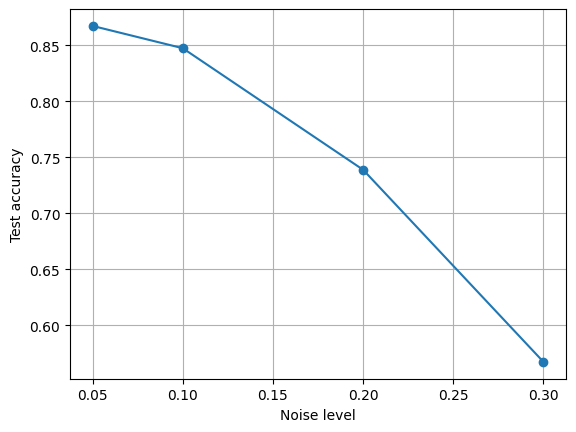

In [ ]:
plt.plot(noise_results_df["noise_level"], noise_results_df["test_accuracy"], marker="o")
plt.xlabel("Noise level")
plt.ylabel("Test accuracy")
plt.grid()
plt.show()

# Выводы

В ходе работы была разработана и исследована нейронная сеть для классификации изображений одежды из набора данных Fashion MNIST.

Основные результаты:

* проведён анализ и подготовка данных;
* реализована модель многослойного перцептрона на PyTorch;
* выполнено обучение модели и оценка качества на тестовой выборке;
* проведён анализ ошибок классификации;
* исследовано влияние оптимизатора и значения learning rate на качество модели;
* выполнена проверка устойчивости модели к шуму.

Наилучшие результаты показала модель с оптимизатором Adam и learning rate = 0.001.

Было установлено, что модель хорошо распознаёт большинство классов одежды, однако испытывает сложности при различении визуально похожих категорий, таких как Shirt, T-shirt/top, Pullover и Coat.

В дальнейшем качество модели может быть улучшено за счёт использования сверточных нейронных сетей (CNN), методов аугментации данных, регуляризации и автоматического подбора гиперпараметров.